# Task 1: Potential Problems in Linear Regression
The purpose of this notebook is to determine how non-linearity, heteroscedasticity, and outliers violate the assumptions of linear regression, how each can be detected through residual plots, and how they can be addressed.

## Non-Linearity

A linear regression model assumes that the relationship between the predictor(s) and response variable is linear (ie. must be a straight line). A non-linear relationship between the variables of interest is a significant issue for a linear regression because all conclusions drawn from the results are likely not accurate. Additionally, the prediction accuracy may be impacted/reduced, as stated in the reading. 

One way to diagnose this issue is to visualize the relationship between the predictor and its response variable. By visualizing the raw data between a single predictor and the response vairable of interest, it is much easier to visualize whether the relationship is truely linear or not. In a relationship with multiple predictors, however, it can be difficult to visualize a multi-dimensional relationship with the response variable. 

Residual plots are a better tool to visually diagnose non-linearity among the predictor(s) and response variable. In a simple linear regression (OLS), the residuals (error = distance between actual response value and predicted response value) is plotted against the predictor. In multiple linear regression, residuals are plotted against the predicted y-values. The residual plot should indicate no clear pattern if linearity truely exits in the relationship. In the event that a pattern does exist, however, then the predictor variable(s) can be transformed using log() or additional transformation methods. 

One remaining question that was not explictly addressed in the reading was: **In a multiple regression model with many predictors, if the residuals plot exhibits a non-linear pattern, how do we identify exactly which predictor is responsible for the violation (ie. which relationship is non-linear)?** To address this, I consulted Claude to create synthetic data with a hidden quadratic relationship for one predictor to demonstrate that a standard multiple linear regression will fail to capture the true underlying pattern. By plotting residuals against individual predictors, it visually isolates the specific variable causing the non-linearity; a general "Residuals vs Fitted" plot cannot capture these individual relationships alone.

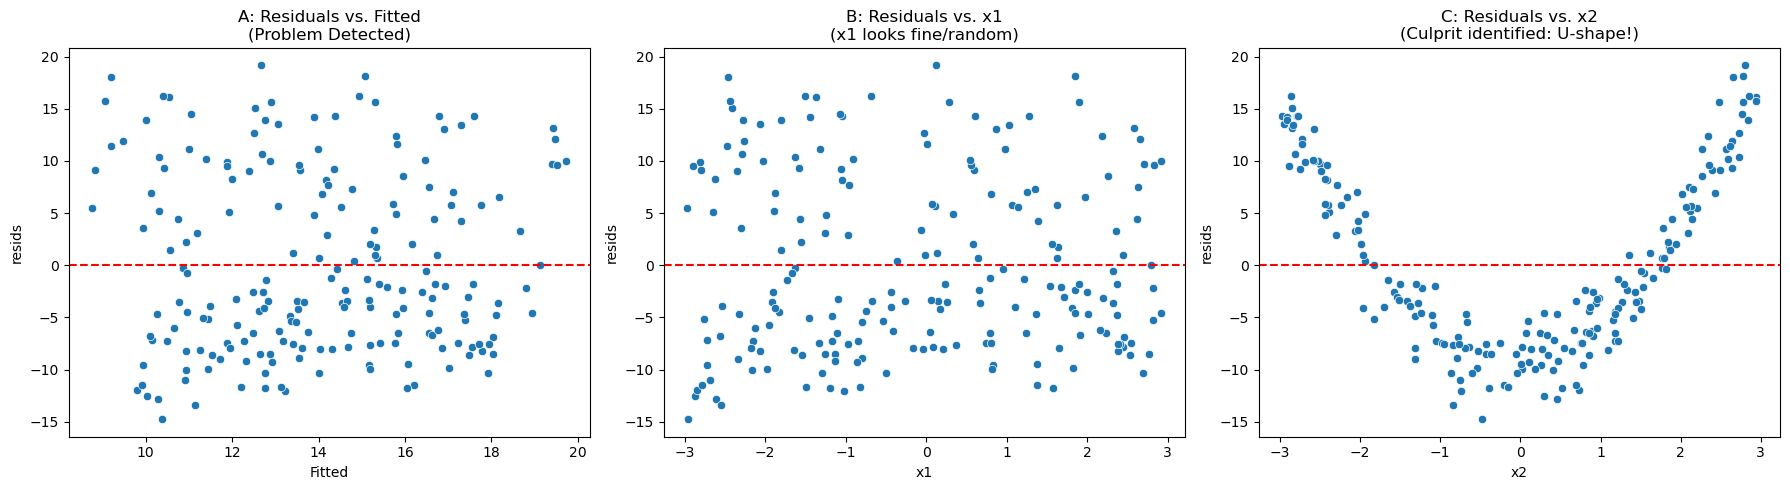

In [1]:
# Import neccessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns

# 1. Generate Synthetic Data
# x1 is linear, x2 is non-linear (quadratic)
np.random.seed(42)
n = 200
x1 = np.random.uniform(-3, 3, n)
x2 = np.random.uniform(-3, 3, n)
noise = np.random.normal(0, 2, n)

# True Relationship: y = 5 + 2*x1 + 3*(x2^2) + noise or error
y = 5 + 2*x1 + 3*(x2**2) + noise
df = pd.DataFrame({'x1': x1, 'x2': x2, 'y': y})

# 2. Fit a standard Multiple Linear Regression (Assuming all are linear)
X = sm.add_constant(df[['x1', 'x2']])
model_linear = sm.OLS(y, X).fit()
df['resids'] = model_linear.resid

# 3. Visualization to isolate the issue
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A: Residuals vs Fitted (The general warning sign)
sns.scatterplot(x=model_linear.fittedvalues, y=df['resids'], ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('A: Residuals vs. Fitted\n(Problem Detected)')
axes[0].set_xlabel("Fitted")

# B: Residuals vs x1 (Testing x1)
sns.scatterplot(x=df['x1'], y=df['resids'], ax=axes[1])
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('B: Residuals vs. x1\n(x1 looks fine/random)')

# C: Residuals vs x2 (Testing x2)
sns.scatterplot(x=df['x2'], y=df['resids'], ax=axes[2])
axes[2].axhline(0, color='red', linestyle='--')
axes[2].set_title('C: Residuals vs. x2\n(Culprit identified: U-shape!)')

plt.tight_layout()
plt.show()

These plots indicate how to spot non-linearity in a linear regression model. The Residuals vs. Fitted plot suggests a problem, and plotting residuals against each predictor shows that `x2` is the predictor with a curved (quadratic) relationship, indicating it needs transformation.

## Non-Constant Variance of Error Terms
Non-constant variance, also known as heteroscedasticity, occurs when the spread of the residuals changes across the range of predictor values. This violates the linear regression assumption that error terms must have uniform variance across all values of the predictor; this is known as homoscedasticity. Heteroscedasticity is a serious issue because standard errors, confidence intervals, and hypothesis tests all depend on the constant-variance assumption. As such, violating this assumption can cause these quantities to become unreliable. 

Homogeneity of variance can be visualized by plotting residuals against fitted values. As stated in the reading, a funnel shape (spread of residuals increases or decreases systematically) is a sign of heteroscedacity. A concave transformation can be applied to the response, such as log(`Y`) or sqrt(`Y`). These transformations compress large values more than small ones, ultimately reducing the growing spread and maintains constant variance. 

**In a simple linear regression model, how can one detect heteroscedasticity in the residuals, and how does a log transformation of the response help correct it?** To illustrate this, I employed Claude to generate synthetic data where the error variance increases with `x` to create a funnel shaped spread. The code fits linear models to both the original `y ` and log(`y`), and then creates three plotted panels: the raw data, the residuals showing the funnel pattern, and the residuals after the log transformation where the funnel disappears. 


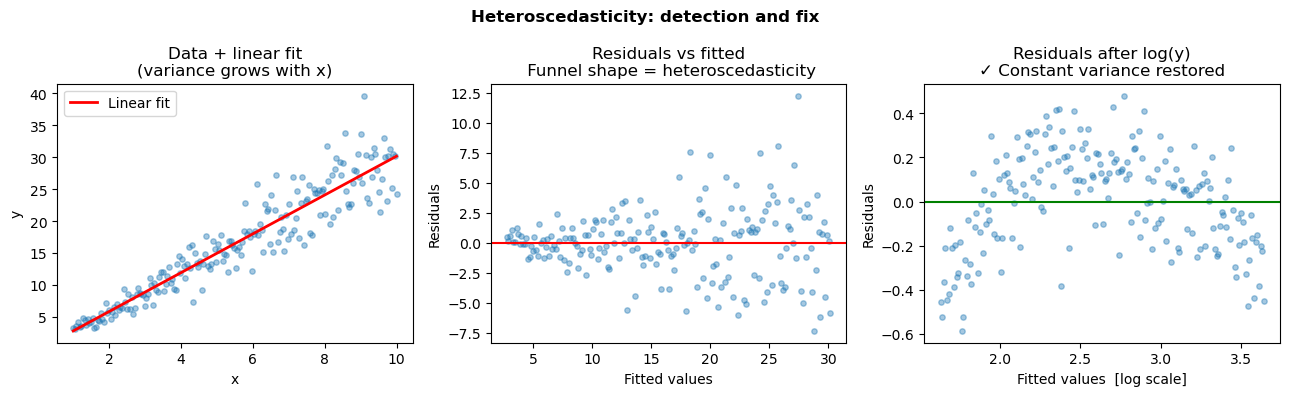

In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

x = np.linspace(1, 10, n)
y = 3 * x + np.random.normal(0, 0.5 * x, n)

# Fit on original y
coef = np.polyfit(x, y, 1)
y_hat = np.polyval(coef, x)
residuals = y - y_hat

# Fit on log(y)
log_y = np.log(y)
coef_log = np.polyfit(x, log_y, 1)
log_y_hat = np.polyval(coef_log, x)
residuals_log = log_y - log_y_hat

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Heteroscedasticity: detection and fix', fontweight='bold')

axes[0].scatter(x, y, alpha=0.4, s=15)
axes[0].plot(x, y_hat, color='red', lw=2, label='Linear fit')
axes[0].set_title('Data + linear fit\n(variance grows with x)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()

axes[1].scatter(y_hat, residuals, alpha=0.4, s=15)
axes[1].axhline(0, color='red', lw=1.5)
axes[1].set_title('Residuals vs fitted\n Funnel shape = heteroscedasticity')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')

axes[2].scatter(log_y_hat, residuals_log, alpha=0.4, s=15)
axes[2].axhline(0, color='green', lw=1.5)
axes[2].set_title('Residuals after log(y)\n✓ Constant variance restored')
axes[2].set_xlabel('Fitted values  [log scale]')
axes[2].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

The succession of plots demonstrate heteroscedasticity by generating a dataset where the error variance expands as the predictor increases, creating a diagnostic "funnel shape" in the initial residual plot. To address this, a log transformation is applied to the response variable, enabling constant spread of residuals across the fitted values; the funnel shape is eliminated. However, there is clear non-linearity following the transformation of the response variable, as indicated by the defined U-shape in the third panel. 

## Outliers
An outlier is an observation whose response value `y` is far from the value predicted by the model. Outliers can origin from a multitude of reasons, such as data entry errors or measurement mistakes. The impact of outliers on regression can be significant. Even if an outlier has little effect on the regression line itself, it can inflate the RSE and deflate the R-squared, making the confidence intervals wider and p-values less reliable.

Residual plots can be used to visually identify the influence of outliers on the model outcome. When plotting residuals against fitted values, outliers appear as points far from zero. A more reliable approach is to plot studentized residuals (each residual divided by its estimated standard error): any observation with an absolute studentized residual > 3 is a candidate outlier.

Outliers can be handled by first determining whether they are recording errors and correcting or removing them. If not, they should be examined to see whether they indicate a missing predictor or a flaw in the model before being dropped.

**How can one detect outliers in a simple regression model? Why do outliers matter even if they barely affect the regression line?** To explore this, I used Claude to generate synthetic data with one extreme outlier that had little impact on the slope but greatly increased the Residual Standard Error (RSE) and reduced R-squared. By computing studentized residuals, the outlier was clearly flagged, underscoring that outliers matter because they have the potential to distort model fit metrics.

RSE  with outlier:    2.342
RSE  without outlier: 0.902
R²   with outlier:    0.932
R²   without outlier: 0.990


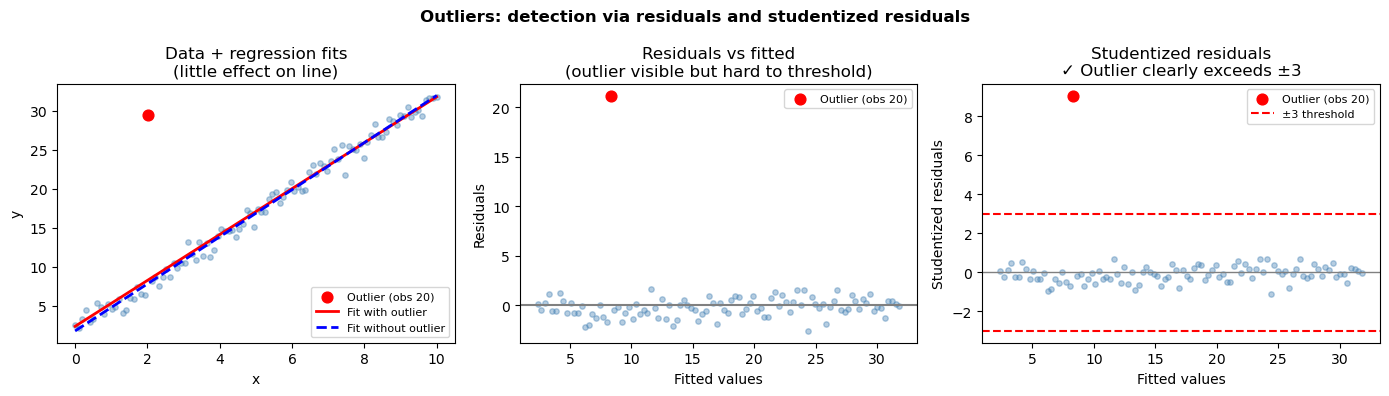

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)
n = 100

# Clean data
x = np.linspace(0, 10, n)
y = 2 + 3 * x + np.random.normal(0, 1, n)

# Inject one outlier at observation 20
y[20] = y[20] + 20

# Fit with outlier
coef = np.polyfit(x, y, 1)
y_hat = np.polyval(coef, x)
residuals = y - y_hat

# Fit without outlier
mask = np.ones(n, dtype=bool)
mask[20] = False
coef_clean = np.polyfit(x[mask], y[mask], 1)
y_hat_clean = np.polyval(coef_clean, x)

# Studentized residuals
rse = np.sqrt(np.sum(residuals**2) / (n - 2))
studentized = residuals / rse

# R² with and without outlier
ss_tot = np.sum((y - np.mean(y))**2)
r2_with = 1 - np.sum(residuals**2) / ss_tot
residuals_clean = y[mask] - np.polyval(coef_clean, x[mask])
ss_tot_clean = np.sum((y[mask] - np.mean(y[mask]))**2)
r2_without = 1 - np.sum(residuals_clean**2) / ss_tot_clean
rse_without = np.sqrt(np.sum(residuals_clean**2) / (n - 3))

print(f"RSE  with outlier:    {rse:.3f}")
print(f"RSE  without outlier: {rse_without:.3f}")
print(f"R²   with outlier:    {r2_with:.3f}")
print(f"R²   without outlier: {r2_without:.3f}")

# --- Plots ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Outliers: detection via residuals and studentized residuals', fontweight='bold')

# Panel 1: scatter + both fits
axes[0].scatter(x, y, alpha=0.4, s=15, color='steelblue')
axes[0].scatter(x[20], y[20], color='red', s=60, zorder=5, label='Outlier (obs 20)')
axes[0].plot(x, y_hat,       color='red',  lw=2,       label='Fit with outlier')
axes[0].plot(x, y_hat_clean, color='blue', lw=2, ls='--', label='Fit without outlier')
axes[0].set_title('Data + regression fits\n(little effect on line)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)

# Panel 2: residual plot
axes[1].scatter(y_hat, residuals, alpha=0.4, s=15, color='steelblue')
axes[1].scatter(y_hat[20], residuals[20], color='red', s=60, zorder=5, label='Outlier (obs 20)')
axes[1].axhline(0, color='gray', lw=1.5)
axes[1].set_title('Residuals vs fitted\n(outlier visible but hard to threshold)')
axes[1].set_xlabel('Fitted values')
axes[1].set_ylabel('Residuals')
axes[1].legend(fontsize=8)

# Panel 3: studentized residuals
axes[2].scatter(y_hat, studentized, alpha=0.4, s=15, color='steelblue')
axes[2].scatter(y_hat[20], studentized[20], color='red', s=60, zorder=5, label='Outlier (obs 20)')
axes[2].axhline(0,  color='gray',  lw=1)
axes[2].axhline(3,  color='red',   lw=1.5, ls='--', label='±3 threshold')
axes[2].axhline(-3, color='red',   lw=1.5, ls='--')
axes[2].set_title('Studentized residuals\n✓ Outlier clearly exceeds ±3')
axes[2].set_xlabel('Fitted values')
axes[2].set_ylabel('Studentized residuals')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

The outlier (obs = 20) barely shifts the regression line; the red and blue dashed fits are nearly identical. Despite this, it more than doubles the RSE and decreases R-squared down from 0.990 to 0.932, showing how a single point can significantly distort model diagnostics without moving the line. The studentized residual plot shows that the detection is unambiguous; the outlier sits above 9 while every other observation falls between −2 and 2 which is below the >= 3 threshold.


## Generative AI Reflection
I utilized Claude to generate code relevant to answer each question for each issue identified. I prompted Claude to generate synthetic data based on the specific issue and model of interest. For example, for heteroscedasticity I asked Claude to simulate data where the error variance grows with `x`, then fit a simple linear regression, and finally produce residual plots showing the funnel shape before and after a log transformation. This typically took about 2-3 iterations per issue. Claude occasionally made minor errors, such as producing residual plots that still showed slight non-linearity after the log transformation fix of the predictor; I caught this error by visually inspecting the output against the expected behavior described in the textbook reading.